In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\JINESHA GANDHI\Downloads\AirPassengers.csv")

# Extract column
data = df['Passengers'].values.reshape(-1,1)

# Normalize data
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

# Create sequences
def create_dataset(data, steps=3):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i:i+steps])
        y.append(data[i+steps])
    return np.array(X), np.array(y)

X, y = create_dataset(data)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.1315 - mae: 0.3041 - val_loss: 0.5033 - val_mae: 0.6930
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1021 - mae: 0.2630 - val_loss: 0.3992 - val_mae: 0.6143
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0777 - mae: 0.2253 - val_loss: 0.3131 - val_mae: 0.5408
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0590 - mae: 0.1926 - val_loss: 0.2414 - val_mae: 0.4718
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0439 - mae: 0.1627 - val_loss: 0.1844 - val_mae: 0.4086
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0324 - mae: 0.1366 - val_loss: 0.1362 - val_mae: 0.3457
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0225 - mae: 0.1111 - val_loss: 0.0967 - val_mae: 0.2834
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0157 - mae: 0.0914 - val_loss: 0.0646 - val_mae: 0.2193
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0104 - mae: 0.0776 - 

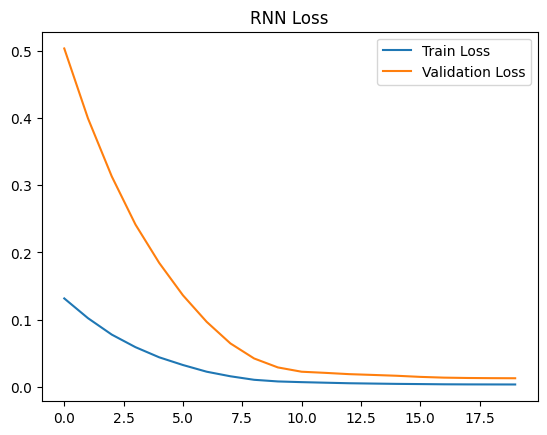

In [3]:
# RNN MODEL
model_rnn = models.Sequential([
    tf.keras.Input(shape=(X.shape[1],1)),
    layers.SimpleRNN(50, activation='relu'),
    layers.Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_rnn = model_rnn.fit(X, y, validation_split=0.2, epochs=20)

# Predict next value (RNN)
last_input = data[-3:]
last_input = last_input.reshape((1,3,1))
next_rnn = model_rnn.predict(last_input)
print("Next value (RNN):", scaler.inverse_transform(next_rnn)[0][0])

# Plot RNN loss
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("RNN Loss")
plt.legend()
plt.show()

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0885 - mae: 0.2475 - val_loss: 0.3604 - val_mae: 0.5824
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0766 - mae: 0.2263 - val_loss: 0.3216 - val_mae: 0.5484
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0653 - mae: 0.2037 - val_loss: 0.2823 - val_mae: 0.5118
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0545 - mae: 0.1824 - val_loss: 0.2433 - val_mae: 0.4725
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0443 - mae: 0.1610 - val_loss: 0.2058 - val_mae: 0.4314
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0353 - mae: 0.1421 - val_loss: 0.1700 - val_mae: 0.3883
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0278 - mae: 0.1239 - val_loss: 0.1368 - val_mae: 0.3433
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0214 - mae: 0.1107 - val_loss: 0.1071 - val_mae: 0.2972
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0175 - mae: 0.1028 -

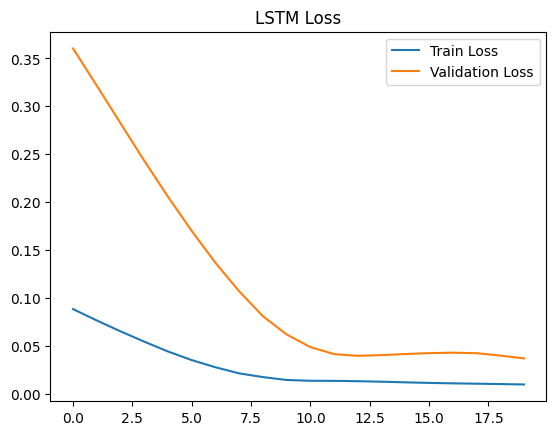

In [4]:
#LSTM MODEL  
model_lstm = models.Sequential([
    tf.keras.Input(shape=(X.shape[1],1)),
    layers.LSTM(50, activation='relu'),
    layers.Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_lstm = model_lstm.fit(X, y, validation_split=0.2, epochs=20)

# Predict next value (LSTM)
next_lstm = model_lstm.predict(last_input)
print("Next value (LSTM):", scaler.inverse_transform(next_lstm)[0][0])

# Plot LSTM loss
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Loss")
plt.legend()
plt.show()

Final RNN Validation Loss: 0.012741545215249062
Final LSTM Validation Loss: 0.03706689178943634


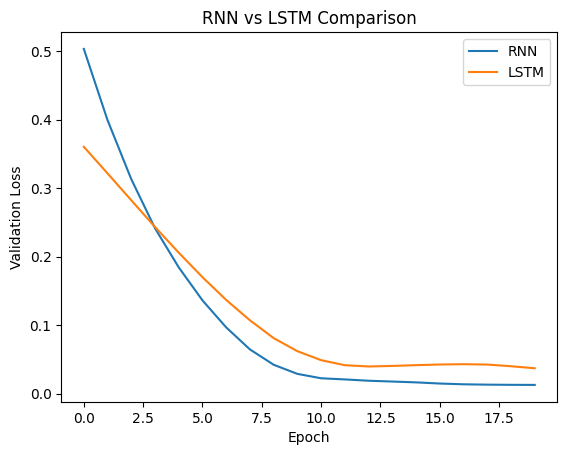

In [5]:
#COMPARISON 
print("Final RNN Validation Loss:", history_rnn.history['val_loss'][-1])
print("Final LSTM Validation Loss:", history_lstm.history['val_loss'][-1])

plt.plot(history_rnn.history['val_loss'], label='RNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.title("RNN vs LSTM Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()